In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
vaccine2023 = pd.read_excel('2023_Data_Vaccine.xlsx', sheet_name='Original')


In [39]:
vaccine2022 = pd.read_excel('Data_2022_Vaccine.xlsx', sheet_name='Sheet1')


In [40]:
vaccine2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 22 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Date                                              628 non-null    object 
 1   Case #                                            628 non-null    object 
 2   Age (months)                                      628 non-null    object 
 3    Sex (F or M) 1=F, 2=M                            628 non-null    int64  
 4   Weight (kg)                                       551 non-null    float64
 5   Medication 1=APAP, 2=IBU                          628 non-null    int64  
 6   Dose (mg) 0=unk                                   628 non-null    float64
 7   Other dose details                                36 non-null     object 
 8   exact or estimate X=exact, E=estimate, M=max amt  628 non-null    object 
 9   Dosage form 1=liquid,

In [41]:
vaccine2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 22 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   Date                                              876 non-null    datetime64[ns]
 1   Case #                                            880 non-null    object        
 2   Age (months)                                      879 non-null    float64       
 3    Sex (F or M) 1=F, 2=M                            879 non-null    float64       
 4   Weight (kg)                                       772 non-null    object        
 5   Medication 1=APAP, 2=IBU                          880 non-null    int64         
 6   Dose (mg) 0=unk                                   880 non-null    float64       
 7   Other dose details                                52 non-null     object        
 8   exact or estimate X=exact, E=e

In [42]:
vaccine2022['Date']=vaccine2022['Date'].replace('12/12/021','12/12/2021')

In [43]:
vaccine2022['Date']=pd.to_datetime(vaccine2022['Date'])

In [44]:
vaccine = pd.merge(vaccine2023, vaccine2022,how='outer')  # Change 'key' and 'how' as needed
vaccine.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1508 entries, 0 to 1507
Data columns (total 24 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   Date                                              1504 non-null   datetime64[ns]
 1   Case #                                            1508 non-null   object        
 2   Age (months)                                      1507 non-null   object        
 3    Sex (F or M) 1=F, 2=M                            1507 non-null   float64       
 4   Weight (kg)                                       1323 non-null   object        
 5   Medication 1=APAP, 2=IBU                          1508 non-null   int64         
 6   Dose (mg) 0=unk                                   1508 non-null   float64       
 7   Other dose details                                88 non-null     object        
 8   exact or estimate X=exact, E

In [47]:
vaccine.head()

,Date,Case #,Age (months),"Sex (F or M) 1=F, 2=M",Weight (kg),"Medication 1=APAP, 2=IBU",Dose (mg) 0=unk,Other dose details,"exact or estimate X=exact, E=estimate, M=max amt","Dosage form 1=liquid, 2=pills, 3=other, 4=unk",...,Reason for TE (case notes),1=acute 2=chronic,"Due to med shortage 1=YES, 2=NO","Referred/call from HCF 1=YES, 2=NO",Outcome (VDL code),Outcome (case notes),"Followed to known outcome (1=YES, 2=NO)",page,Other dosage from details,Unnamed: 21
0,2022-12-02,009-2450568,48.0,2.0,23.6,1,320.0,NaN,x,1,...,DWRG,1,2,2,5,5,2,NaN,NaN,NaN
1,2022-12-03,009-2451143,4.0,2.0,7.7,1,160.0,NaN,x,1,...,DOTR,1,2,2,5,5,2,NaN,NaN,NaN
2,2022-12-12,009-2454501,36.0,2.0,19.1,1,480.0,NaN,x,1,...,DDBL,1,2,2,5,5,2,NaN,NaN,NaN
3,2022-12-12,009-2454616,36.0,1.0,15.5,1,448.0,NaN,x,1,...,DOTR,1,2,2,5,5,2,NaN,NaN,NaN
4,2022-12-22,009-2458737,2.0,2.0,4.1,1,160.0,NaN,x,1,...,DOTR,1,2,2,5,5,2,NaN,NaN,NaN


In [46]:
vaccine2022.tail()

,Date,Case #,Age (months),"Sex (F or M) 1=F, 2=M",Weight (kg),"Medication 1=APAP, 2=IBU",Dose (mg) 0=unk,Other dose details,"exact or estimate X=exact, E=estimate, M=max amt","Dosage form 1=liquid, 2=pills, 3=other, 4=unk",...,Other route details,Reason for TE (VDL code),Reason for TE (case notes),1=acute 2=chronic,"Due to med shortage 1=YES, 2=NO","Referred/call from HCF 1=YES, 2=NO",Outcome (VDL code),Outcome (case notes),"Followed to known outcome (1=YES, 2=NO)",Unnamed: 21
623,2022-01-14,014-2325125,5,1,4.5,1,320.0,NaN,x,1,...,NaN,DDBL,DDBL,2,2,1,0,0,1,NaN
624,2022-02-11,014-4086825,1,2,4.5,1,160.0,NaN,x,1,...,NaN,DUNK,DUNK,1,2,1,0,6,2,NaN
625,2022-01-24,028-2328921,120,1,41.0,2,800.0,NaN,x,2,...,NaN,DOTR,DOTR,1,2,1,0,0,1,NaN
626,2022-01-19,084-2327018,2,2,6.9,1,640.0,NaN,x,1,...,NaN,DUNK,DUNK,2,2,1,0,0,1,NaN
627,2022-03-24,009-2351376,3,1,5.9,1,128.0,NaN,x,1,...,NaN,DDBL,DDBL,1,2,1,5,5,2,NaN


In [48]:
vaccine = vaccine.rename(columns={'Dose (mg) 0=unk':'Dose(mg)',
                                          ' Sex (F or M) 1=F, 2=M':'Sex',
                                          'Medication 1=APAP, 2=IBU':'Medication',
                                         'Dosage form 1=liquid, 2=pills, 3=other, 4=unk':'Dosage Form',
                                         'Outcome (VDL code)':'Outcome(VDL)',
                                         'Reason for TE (VDL code)':'Reason For TE(VDL)',
                                         'Due to med shortage 1=YES, 2=NO':'Due to med shortage'})

In [49]:
vaccine.head()

,Date,Case #,Age (months),Sex,Weight (kg),Medication,Dose(mg),Other dose details,"exact or estimate X=exact, E=estimate, M=max amt",Dosage Form,...,Reason for TE (case notes),1=acute 2=chronic,Due to med shortage,"Referred/call from HCF 1=YES, 2=NO",Outcome(VDL),Outcome (case notes),"Followed to known outcome (1=YES, 2=NO)",page,Other dosage from details,Unnamed: 21
0,2022-12-02,009-2450568,48.0,2.0,23.6,1,320.0,NaN,x,1,...,DWRG,1,2,2,5,5,2,NaN,NaN,NaN
1,2022-12-03,009-2451143,4.0,2.0,7.7,1,160.0,NaN,x,1,...,DOTR,1,2,2,5,5,2,NaN,NaN,NaN
2,2022-12-12,009-2454501,36.0,2.0,19.1,1,480.0,NaN,x,1,...,DDBL,1,2,2,5,5,2,NaN,NaN,NaN
3,2022-12-12,009-2454616,36.0,1.0,15.5,1,448.0,NaN,x,1,...,DOTR,1,2,2,5,5,2,NaN,NaN,NaN
4,2022-12-22,009-2458737,2.0,2.0,4.1,1,160.0,NaN,x,1,...,DOTR,1,2,2,5,5,2,NaN,NaN,NaN


In [50]:
vaccine['Sex']=vaccine['Sex'].apply(lambda x: 'Female' if x==1 else 'Male')
vaccine['Medication']=vaccine['Medication'].apply(lambda x: 'APAP' if x ==1 else 'IBU')
vaccine['Due to med shortage']=vaccine['Due to med shortage'].apply(lambda x: 'Yes' if x ==1 else 'No')
vaccine.head()

,Date,Case #,Age (months),Sex,Weight (kg),Medication,Dose(mg),Other dose details,"exact or estimate X=exact, E=estimate, M=max amt",Dosage Form,...,Reason for TE (case notes),1=acute 2=chronic,Due to med shortage,"Referred/call from HCF 1=YES, 2=NO",Outcome(VDL),Outcome (case notes),"Followed to known outcome (1=YES, 2=NO)",page,Other dosage from details,Unnamed: 21
0,2022-12-02,009-2450568,48.0,Male,23.6,APAP,320.0,NaN,x,1,...,DWRG,1,No,2,5,5,2,NaN,NaN,NaN
1,2022-12-03,009-2451143,4.0,Male,7.7,APAP,160.0,NaN,x,1,...,DOTR,1,No,2,5,5,2,NaN,NaN,NaN
2,2022-12-12,009-2454501,36.0,Male,19.1,APAP,480.0,NaN,x,1,...,DDBL,1,No,2,5,5,2,NaN,NaN,NaN
3,2022-12-12,009-2454616,36.0,Female,15.5,APAP,448.0,NaN,x,1,...,DOTR,1,No,2,5,5,2,NaN,NaN,NaN
4,2022-12-22,009-2458737,2.0,Male,4.1,APAP,160.0,NaN,x,1,...,DOTR,1,No,2,5,5,2,NaN,NaN,NaN


In [73]:
vaccine.loc[:][['Date','Case #','Dose(mg)','Age (months)','Sex','Weight (kg)','Reason For TE(VDL)','Outcome(VDL)','1=acute 2=chronic']]

,Date,Case #,Dose(mg),Age (months),Sex,Weight (kg),Reason For TE(VDL),Outcome(VDL),1=acute 2=chronic
0,2022-12-02,009-2450568,320.0,48.0,Male,23.6,DTSN,5,1
1,2022-12-03,009-2451143,160.0,4.0,Male,7.7,DOTR,5,1
2,2022-12-12,009-2454501,480.0,36.0,Male,19.1,DDBL,5,1
3,2022-12-12,009-2454616,448.0,36.0,Female,15.5,DOTR,5,1
4,2022-12-22,009-2458737,160.0,2.0,Male,4.1,DOTR,5,1
...,...,...,...,...,...,...,...,...,...
1503,2022-01-14,014-2325125,320.0,5,Female,4.5,DDBL,0,2
1504,2022-02-11,014-4086825,160.0,1,Male,4.5,DUNK,0,1
1505,2022-01-24,028-2328921,800.0,120,Female,41.0,DOTR,0,1
1506,2022-01-19,084-2327018,640.0,2,Male,6.9,DUNK,0,2


In [72]:
vaccine.loc[:][['Date']]

,Date
0,2022-12-02
1,2022-12-03
2,2022-12-12
3,2022-12-12
4,2022-12-22
...,...
1503,2022-01-14
1504,2022-02-11
1505,2022-01-24
1506,2022-01-19


<Axes: xlabel='Reason For TE(VDL)'>

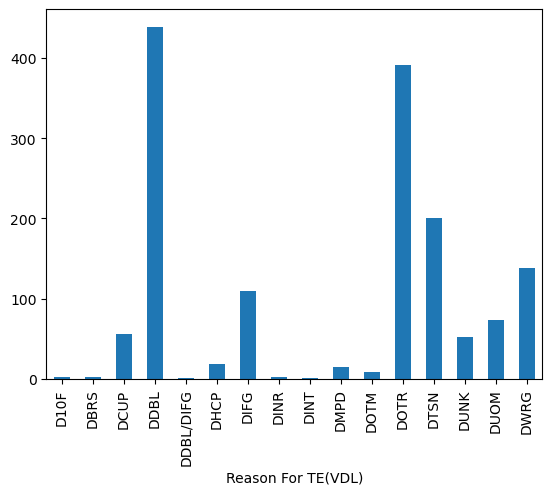

In [51]:
vaccine.groupby('Reason For TE(VDL)')['Case #'].count().plot.bar()

In [54]:
vaccine['Date'] = pd.to_datetime(vaccine['Date'], errors='coerce')
vaccine['Year'] = vaccine['Date'].dt.year

In [56]:
grouped_data = vaccine.groupby(['Year', 'Reason For TE(VDL)'])['Case #'].count().unstack()

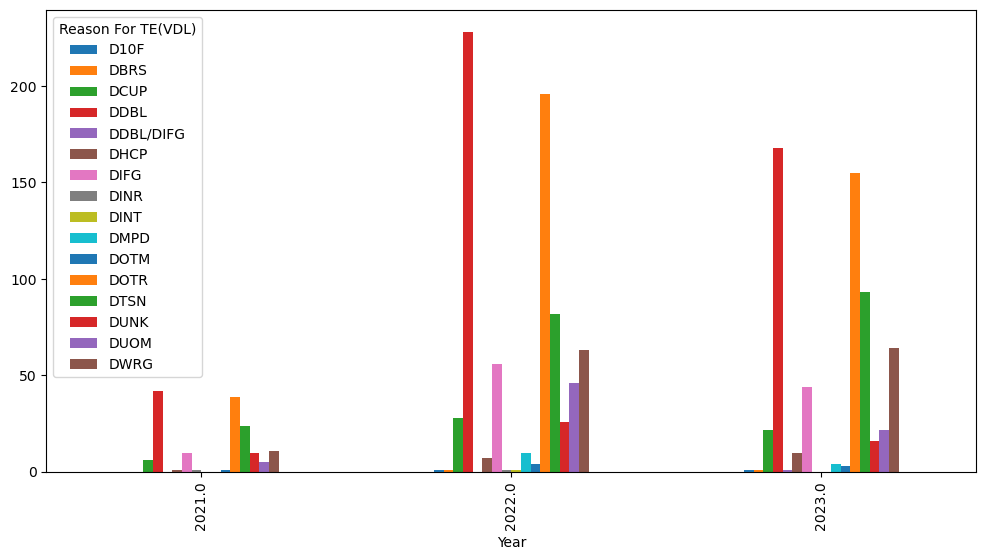

In [57]:
ax = grouped_data.plot(kind='bar', figsize=(12, 6))

In [61]:
grouped_data = vaccine.groupby(['Reason For TE(VDL)', 'Year'])['Case #'].count().unstack()

In [63]:
grouped_data.columns = grouped_data.columns.astype(int)

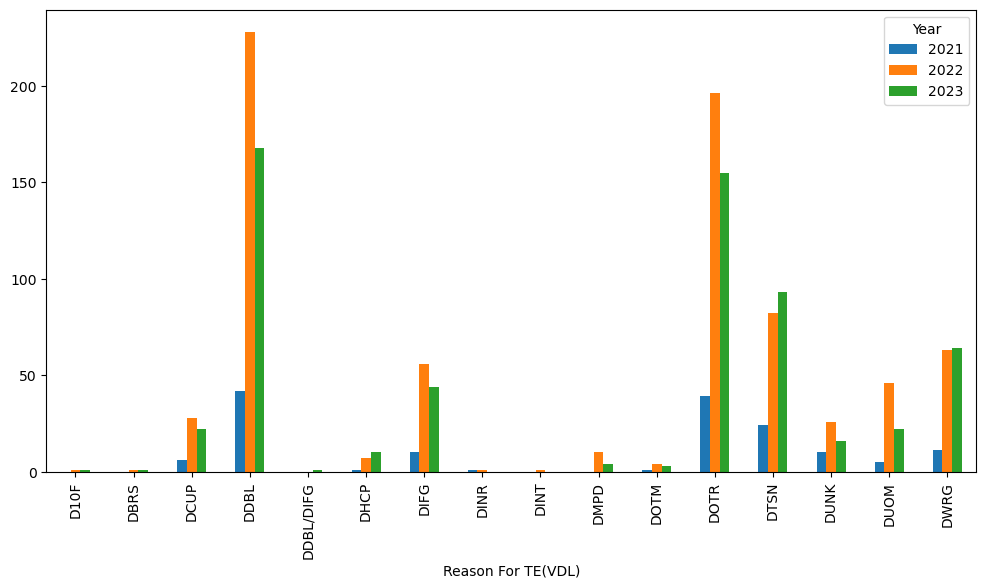

In [64]:
ax = grouped_data.plot(kind='bar', figsize=(12, 6))

In [76]:
vaccine['Date'] = pd.to_datetime(vaccine['Date'])

In [94]:
def define_period(date):
    if (date >= pd.Timestamp('2021-11-01')) and (date <= pd.Timestamp('2022-04-30')):
        return '2022'
    else:
        return '2023'

vaccine['Custom Period'] = vaccine['Date'].apply(define_period)



In [95]:
vaccine.tail()

,Date,Case #,Age (months),Sex,Weight (kg),Medication,Dose(mg),Other dose details,"exact or estimate X=exact, E=estimate, M=max amt",Dosage Form,...,Due to med shortage,"Referred/call from HCF 1=YES, 2=NO",Outcome(VDL),Outcome (case notes),"Followed to known outcome (1=YES, 2=NO)",page,Other dosage from details,Unnamed: 21,Year,Custom Period
1503,2022-01-14,014-2325125,5,Female,4.5,APAP,320.0,NaN,x,1,...,No,1,0,0,1,NaN,NaN,NaN,2022.0,2022
1504,2022-02-11,014-4086825,1,Male,4.5,APAP,160.0,NaN,x,1,...,No,1,0,6,2,NaN,NaN,NaN,2022.0,2022
1505,2022-01-24,028-2328921,120,Female,41.0,IBU,800.0,NaN,x,2,...,No,1,0,0,1,NaN,NaN,NaN,2022.0,2022
1506,2022-01-19,084-2327018,2,Male,6.9,APAP,640.0,NaN,x,1,...,No,1,0,0,1,NaN,NaN,NaN,2022.0,2022
1507,2022-03-24,009-2351376,3,Female,5.9,APAP,128.0,NaN,x,1,...,No,1,5,5,2,NaN,NaN,NaN,2022.0,2022


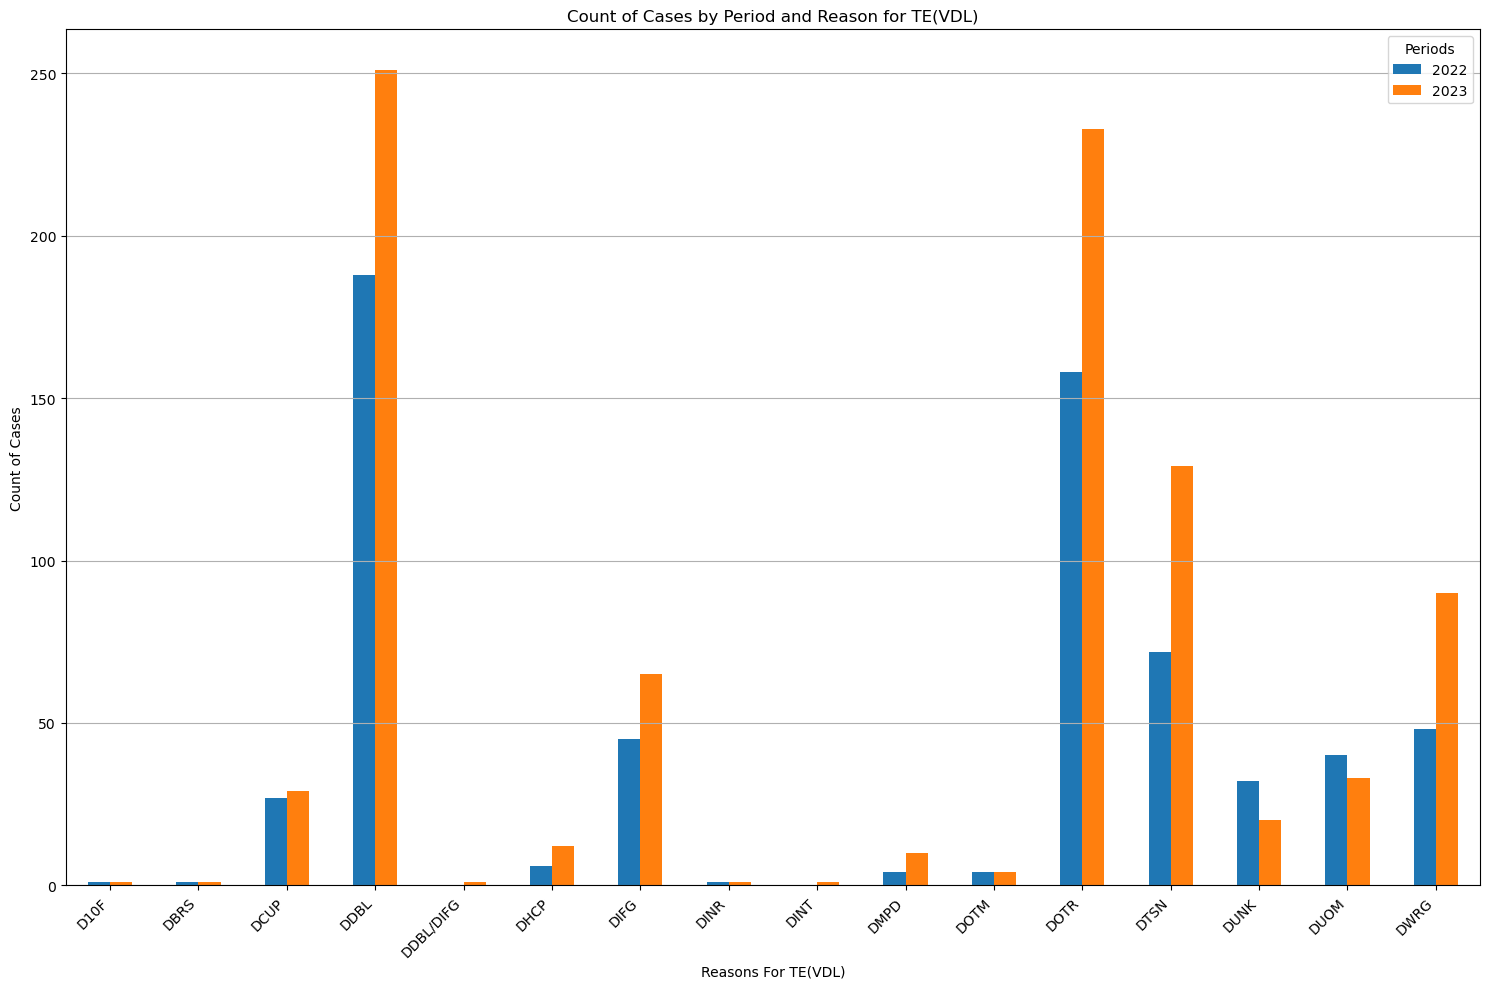

In [96]:
grouped_data = vaccine.groupby(['Reason For TE(VDL)', 'Custom Period'])['Case #'].count().unstack()
grouped_data.columns = grouped_data.columns.astype(int)
ax = grouped_data.plot(kind='bar', figsize=(15, 10))

plt.title('Count of Cases by Period and Reason for TE(VDL)')
plt.xlabel('Reasons For TE(VDL)')
plt.ylabel('Count of Cases')
plt.xticks(rotation=45, ha='right') 
plt.legend(title='Periods')
plt.grid(axis='y') 
plt.tight_layout()

plt.show()